In [70]:
#%pip install cfbd

In [71]:
from __future__ import print_function
import time
import cfbd
from cfbd.rest import ApiException
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [72]:
# Configure API key authorization: ApiKeyAuth
configuration = cfbd.Configuration()
configuration.api_key['Authorization'] = 'aiS0bBk23RvX4eOWirh4JQgCK+UIO0k1AF/9A2RDyu2D6D/u1LLVKvdDKdHQokqF'
configuration.api_key_prefix['Authorization'] = 'Bearer'

In [73]:
# create an instance of the API class
api_instance = cfbd.GamesApi(cfbd.ApiClient(configuration))
games = api_instance.get_games(year=2021)
df = pd.DataFrame.from_records([g.to_dict() for g in games])

In [74]:
sooners_home_games = df[df['home_team'] == 'Oklahoma']
sooners_away_games = df[df['away_team'] == 'Oklahoma']


In [75]:
# Assuming each row in the data frame represents a game
sooners_home_games['game_date'] = pd.to_datetime(sooners_home_games['start_date'])
sooners_away_games['game_date'] = pd.to_datetime(sooners_away_games['start_date'])

# Sort games by date
sooners_home_games = sooners_home_games.sort_values('game_date')
sooners_away_games = sooners_away_games.sort_values('game_date')


# Calculate cumulative points scored and conceded over the season
sooners_home_games['cumulative_points_scored'] = sooners_home_games['home_points'].cumsum()
sooners_home_games['cumulative_points_conceded'] = sooners_home_games['away_points'].cumsum()
sooners_away_games['cumulative_points_scored'] = sooners_away_games['away_points'].cumsum()
sooners_away_games['cumulative_points_conceded'] = sooners_away_games['home_points'].cumsum()


C:\Users\Ben\AppData\Local\Temp\ipykernel_40240\1333505724.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sooners_home_games['game_date'] = pd.to_datetime(sooners_home_games['start_date'])
C:\Users\Ben\AppData\Local\Temp\ipykernel_40240\1333505724.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sooners_away_games['game_date'] = pd.to_datetime(sooners_away_games['start_date'])


In [76]:
# Combine home and away games into one dataframe for plotting
all_games = pd.concat([sooners_home_games, sooners_away_games])

# Reset the index
all_games.reset_index(drop=True, inplace=True)

# Sort games by date
all_games = all_games.sort_values('game_date')

# Determine if Oklahoma is the home or away team for each game
all_games['is_home'] = all_games['home_team'] == 'Oklahoma Sooners'

# Create columns for points scored and points conceded
all_games['points_scored'] = all_games.apply(lambda row: row['home_points'] if row['is_home'] else row['away_points'], axis=1)
all_games['points_conceded'] = all_games.apply(lambda row: row['away_points'] if row['is_home'] else row['home_points'], axis=1)

# Calculate cumulative points scored and conceded over the season
all_games['cumulative_points_scored'] = all_games['points_scored'].cumsum()
all_games['cumulative_points_conceded'] = all_games['points_conceded'].cumsum()


C:\Users\Ben\AppData\Local\Temp\ipykernel_40240\3381288679.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sooners_games['game_number'] = range(1, len(sooners_games) + 1)  # Add game number column
C:\Users\Ben\AppData\Local\Temp\ipykernel_40240\3381288679.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sooners_games['is_home'] = sooners_games['home_team'] == 'Oklahoma'
C:\Users\Ben\AppData\Local\Temp\ipykernel_40240\3381288679.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

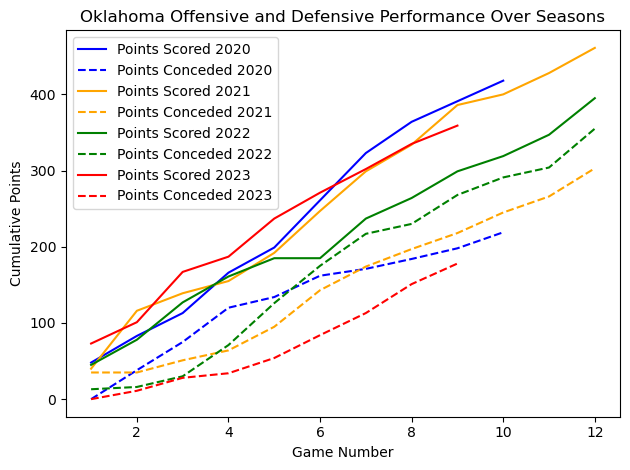

In [77]:

# Define a function to get and process games data for a specific year
def get_year_data(year):
    api_instance = cfbd.GamesApi(cfbd.ApiClient(configuration))  # Create API instance here
    games = api_instance.get_games(year=year)
    df = pd.DataFrame.from_records([g.to_dict() for g in games])
    sooners_games = df[(df['home_team'] == 'Oklahoma') | (df['away_team'] == 'Oklahoma')]
    sooners_games['game_number'] = range(1, len(sooners_games) + 1)  # Add game number column
    sooners_games['is_home'] = sooners_games['home_team'] == 'Oklahoma'
    sooners_games['points_scored'] = sooners_games.apply(lambda row: row['home_points'] if row['is_home'] else row['away_points'], axis=1)
    sooners_games['points_conceded'] = sooners_games.apply(lambda row: row['away_points'] if row['is_home'] else row['home_points'], axis=1)
    sooners_games['cumulative_points_scored'] = sooners_games['points_scored'].cumsum()
    sooners_games['cumulative_points_conceded'] = sooners_games['points_conceded'].cumsum()
    return sooners_games

# Get data for each year
years = [2020, 2021, 2022, 2023]
data_per_year = {year: get_year_data(year) for year in years}

# Plot data
fig, ax = plt.subplots()

colors = ['blue', 'orange', 'green', 'red']  # Define colors for each year
for i, (year, data) in enumerate(data_per_year.items()):
    ax.plot(data['game_number'], data['cumulative_points_scored'], label=f'Points Scored {year}', color=colors[i])
    ax.plot(data['game_number'], data['cumulative_points_conceded'], label=f'Points Conceded {year}', linestyle='dashed', color=colors[i])

ax.set_xlabel('Game Number')
ax.set_ylabel('Cumulative Points')
ax.set_title('Oklahoma Offensive and Defensive Performance Over Seasons')
ax.legend()

plt.tight_layout()
plt.show()


C:\Users\Ben\AppData\Local\Temp\ipykernel_40240\2794468501.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis", len(years))  # Choose any colormap that you like


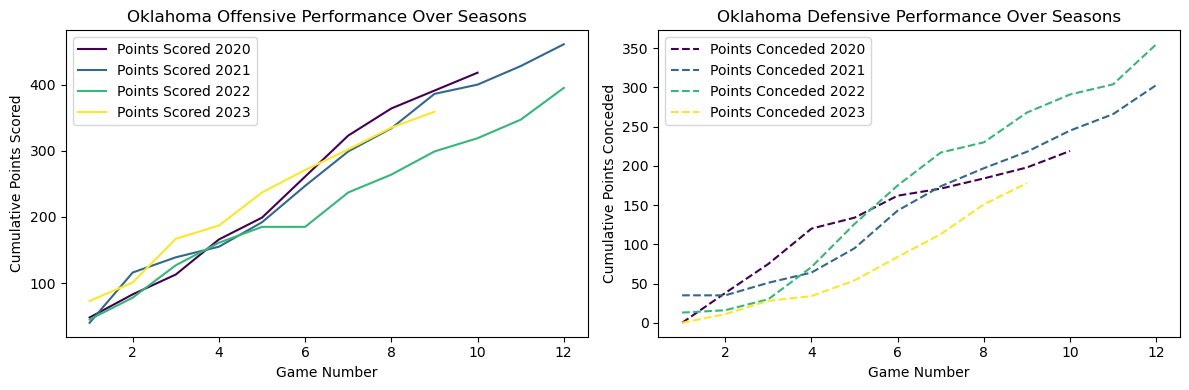

In [78]:
# Plot data
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Define a colormap
cmap = plt.cm.get_cmap("viridis", len(years))  # Choose any colormap that you like

for i, (year, data) in enumerate(data_per_year.items()):
    color = cmap(i)
    axs[0].plot(data['game_number'], data['cumulative_points_scored'], label=f'Points Scored {year}', color=color)
    axs[1].plot(data['game_number'], data['cumulative_points_conceded'], label=f'Points Conceded {year}', linestyle='dashed', color=color)

axs[0].set_xlabel('Game Number')
axs[0].set_ylabel('Cumulative Points Scored')
axs[0].set_title('Oklahoma Offensive Performance Over Seasons')
axs[0].legend()

axs[1].set_xlabel('Game Number')
axs[1].set_ylabel('Cumulative Points Conceded')
axs[1].set_title('Oklahoma Defensive Performance Over Seasons')
axs[1].legend()

plt.tight_layout()
plt.show()